# Week 11 Lab — Clustering & Dimensionality Reduction (Instructor Version)

**Goal:** Apply PCA and K-Means to 114,000 Spotify tracks. Discover what structure emerges from audio features alone — without using the genre label.

By the end of this lab you will:
1. Scale features and understand why scaling matters for distance-based methods
2. Apply PCA to reduce 10 dimensions to 2–3 principal components
3. Use the elbow method and silhouette score to pick *K* for K-Means
4. Visualize clusters with t-SNE and compare them to genre labels

## Part 1: Setup

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.stat import Correlation

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

spark = SparkSession.builder.appName("Clustering_Lab_Instructor").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

## Part 2: Load & Explore the Data

In [43]:
df = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("quote", '"')
    .option("escape", '"')
    .option("multiLine", "true")
    .csv("spotify.csv")
)
print(f"Rows: {df.count():,}")
print(f"Columns: {len(df.columns)}")
df.printSchema()

Rows: 114,000
Columns: 21
root
 |-- _c0: integer (nullable = true)
 |-- track_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- popularity: integer (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- explicit: boolean (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- time_signature: integer (nullable = true)
 |-- track_genre: string (nullable = true)



In [44]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

df.select(audio_features).describe().show()

+-------+-------------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+
|summary|       danceability|            energy|          loudness|        speechiness|      acousticness|   instrumentalness|           liveness|           valence|             tempo|       duration_ms|
+-------+-------------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+
|  count|             114000|            114000|            114000|             114000|            114000|             114000|             114000|            114000|            114000|            114000|
|   mean| 0.5668000657894607|0.6413827583964953|-8.258960368421159|0.08465211228070163|0.3149100624799954|0.15604958922122655|0.21355283605263073|0.4740682309736918|122.14783728947668|

In [45]:
# How many genres?
genre_counts = df.groupBy("track_genre").count().orderBy(F.desc("count"))
print(f"Number of genres: {genre_counts.count()}")
genre_counts.show(10)

Number of genres: 114
+-----------------+-----+
|      track_genre|count|
+-----------------+-----+
|            anime| 1000|
|singer-songwriter| 1000|
|             folk| 1000|
|        hardstyle| 1000|
|              pop| 1000|
|      alternative| 1000|
|      death-metal| 1000|
|   detroit-techno| 1000|
|              idm| 1000|
|            k-pop| 1000|
+-----------------+-----+
only showing top 10 rows


In [ ]:
# Drop nulls in audio features
before = df.count()
df = df.na.drop(subset=audio_features)
after = df.count()
print(f"Rows before: {before:,} | After: {after:,} | Dropped: {before - after}")

# Keep full dataset for the genre map later
df_full = df

### Focus on Acoustically Distinct Genres

114 genres is too noisy — pop and dance sound identical, alt-rock and rock overlap. To see clear clusters, we pick 6 genres with very different audio profiles: **classical, death-metal, hip-hop, ambient, EDM, comedy**. Later we'll zoom out to all 114 genres in a genre map.

In [72]:
# Filter to 6 acoustically distinct genres
selected_genres = ["classical", "death-metal", "hip-hop", "ambient", "edm", "comedy"]
df = df.filter(F.col("track_genre").isin(selected_genres))

print(f"Filtered rows: {df.count():,}")
df.groupBy("track_genre").count().orderBy(F.desc("count")).show()

Filtered rows: 6,000
+-----------+-----+
|track_genre|count|
+-----------+-----+
|death-metal| 1000|
|    ambient| 1000|
|        edm| 1000|
|    hip-hop| 1000|
|  classical| 1000|
|     comedy| 1000|
+-----------+-----+



Text(0, 0.5, 'Valence')

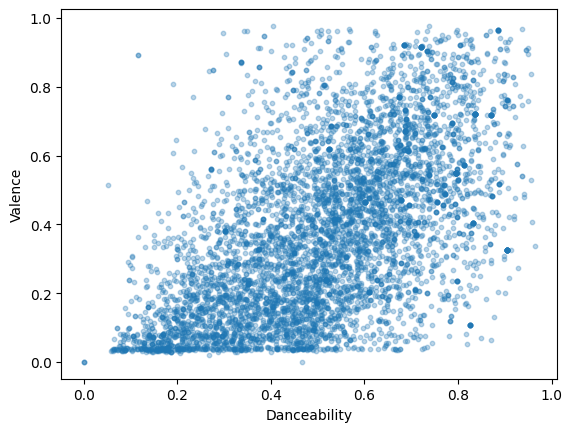

In [76]:
pdf = df.select('danceability', 'valence', 'track_genre').toPandas()
plt.scatter(pdf['danceability'], pdf['valence'], alpha=0.3, s=10)
plt.xlabel('Danceability')
plt.ylabel('Valence')

### Correlation Matrix

In [47]:
assembler_corr = VectorAssembler(inputCols=audio_features, outputCol="features_vec")
vec_df = assembler_corr.transform(df).select("features_vec")
corr_matrix = Correlation.corr(vec_df, "features_vec").head()[0]
corr_array = corr_matrix.toArray()

# Print correlation pairs
print("Notable correlations:")
for i in range(len(audio_features)):
    for j in range(i+1, len(audio_features)):
        r = corr_array[i][j]
        if abs(r) > 0.3:
            print(f"  {audio_features[i]:20s} — {audio_features[j]:20s}: {r:+.3f}")

Notable correlations:
  danceability         — valence             : +0.477
  energy               — loudness            : +0.762
  energy               — acousticness        : -0.734
  loudness             — acousticness        : -0.590
  loudness             — instrumentalness    : -0.433
  instrumentalness     — valence             : -0.324


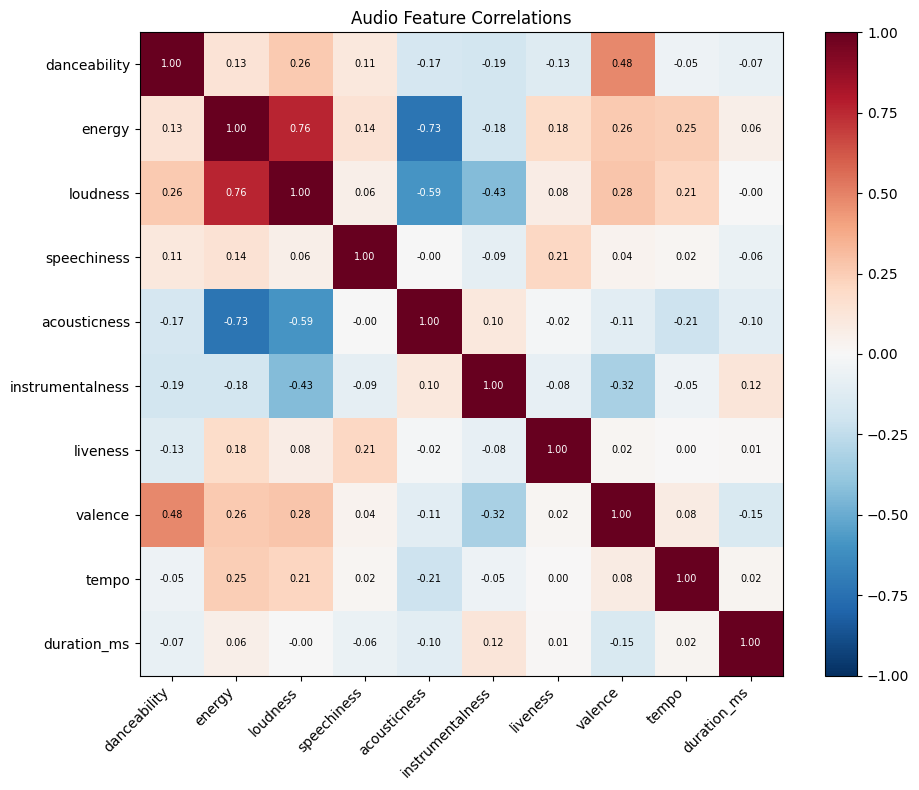

In [48]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_array, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(audio_features)))
ax.set_yticks(range(len(audio_features)))
ax.set_xticklabels(audio_features, rotation=45, ha="right")
ax.set_yticklabels(audio_features)

# Add correlation values in cells
for i in range(len(audio_features)):
    for j in range(len(audio_features)):
        ax.text(j, i, f"{corr_array[i][j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_array[i][j]) > 0.5 else "black", fontsize=7)

plt.colorbar(im)
plt.title("Audio Feature Correlations")
plt.tight_layout()
plt.show()

## Part 3: Feature Preparation — Assemble & Scale

In [49]:
assembler = VectorAssembler(inputCols=audio_features, outputCol="raw_features")

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

assembled = assembler.transform(df)
scaler_model = scaler.fit(assembled)
scaled_df = scaler_model.transform(assembled)

print("✓ Features assembled and scaled")
scaled_df.select("track_name", "track_genre", "scaled_features").show(5, truncate=40)

✓ Features assembled and scaled
+--------------------------+-----------+----------------------------------------+
|                track_name|track_genre|                         scaled_features|
+--------------------------+-----------+----------------------------------------+
|                    Comedy|   acoustic|[0.6292414802920263,-0.71714477875358...|
|          Ghost - Acoustic|   acoustic|[-0.8459042706589345,-1.8899714480702...|
|            To Begin Again|   acoustic|[-0.742183085045195,-1.12266450848340...|
|Can't Help Falling In Love|   acoustic|[-1.7332966364653715,-2.3129841857491...|
|                   Hold On|   acoustic|[0.29502877109219905,-0.7887070840000...|
+--------------------------+-----------+----------------------------------------+
only showing top 5 rows


## Part 4: PCA — Dimensionality Reduction

### Step 1: Fit PCA with all 10 components

In [50]:
pca_full = PCA(k=10, inputCol="scaled_features", outputCol="pca_all")
pca_full_model = pca_full.fit(scaled_df)
explained_variance = pca_full_model.explainedVariance

cumulative = 0
print(f"{'PC':>4} {'Variance':>10} {'Cumulative':>12}")
print("-" * 30)
for i, v in enumerate(explained_variance):
    cumulative += v
    print(f"PC{i+1:>2} {v:>10.4f} {cumulative:>12.4f}")

  PC   Variance   Cumulative
------------------------------
PC 1     0.2874       0.2874
PC 2     0.1524       0.4398
PC 3     0.1234       0.5632
PC 4     0.0971       0.6603
PC 5     0.0887       0.7490
PC 6     0.0834       0.8323
PC 7     0.0748       0.9071
PC 8     0.0463       0.9535
PC 9     0.0325       0.9860
PC10     0.0140       1.0000


### Step 2: Scree Plot

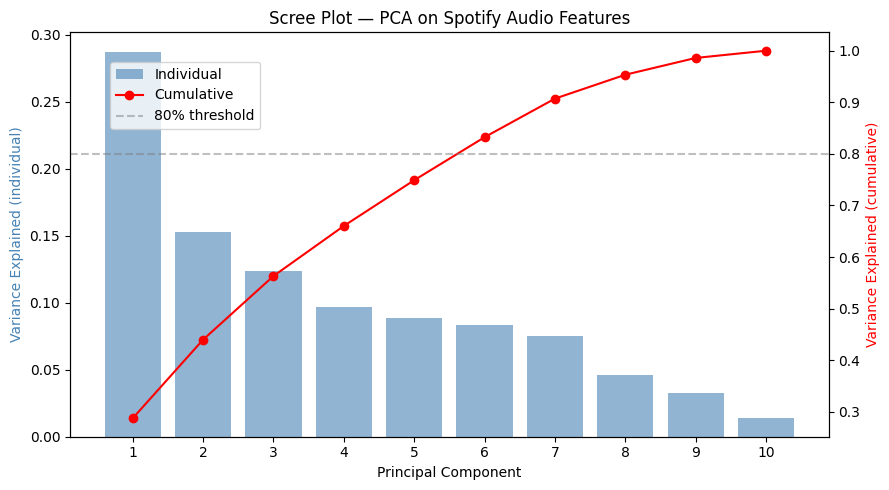


→ 6 components needed for ≥80% variance (83.2%)


In [51]:
ev = list(explained_variance)
cum_ev = np.cumsum(ev)

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(range(1, 11), ev, alpha=0.6, color="steelblue", label="Individual")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (individual)", color="steelblue")
ax1.set_xticks(range(1, 11))

ax2 = ax1.twinx()
ax2.plot(range(1, 11), cum_ev, 'ro-', label="Cumulative")
ax2.set_ylabel("Variance Explained (cumulative)", color="red")
ax2.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label="80% threshold")

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.title("Scree Plot — PCA on Spotify Audio Features")
plt.tight_layout()
plt.show()

# How many components for 80%?
for i, c in enumerate(cum_ev):
    if c >= 0.80:
        print(f"\n→ {i+1} components needed for ≥80% variance ({c:.1%})")
        break

### Step 3: Transform with chosen number of components

In [52]:
# Use 3 components (adjust based on scree plot results)
n_components = 3

pca_final = PCA(k=n_components, inputCol="scaled_features", outputCol="pca_features")
pca_final_model = pca_final.fit(scaled_df)
pca_df = pca_final_model.transform(scaled_df)

total_var = sum(list(pca_final_model.explainedVariance))
print(f"✓ Reduced from 10 features to {n_components} principal components")
print(f"  Total variance retained: {total_var:.1%}")
pca_df.select("track_name", "pca_features").show(5, truncate=60)

✓ Reduced from 10 features to 3 principal components
  Total variance retained: 56.3%
+--------------------------+------------------------------------------------------------+
|                track_name|                                                pca_features|
+--------------------------+------------------------------------------------------------+
|                    Comedy|[-0.6416290551148699,1.0222482320002837,-0.6232537194388889]|
|          Ghost - Acoustic| [3.317621213205932,1.3090224747950585,-0.41152358814232315]|
|            To Begin Again|[1.3860084187774047,-0.16408701603010148,0.13520296119256...|
|Can't Help Falling In Love| [3.375366382806738,-0.3309865212069811,-0.1814899628676446]|
|                   Hold On|  [0.9844260990131735,0.3015626674489631,0.4471887800332884]|
+--------------------------+------------------------------------------------------------+
only showing top 5 rows


### PCA 2D Scatter (for comparison with t-SNE later)

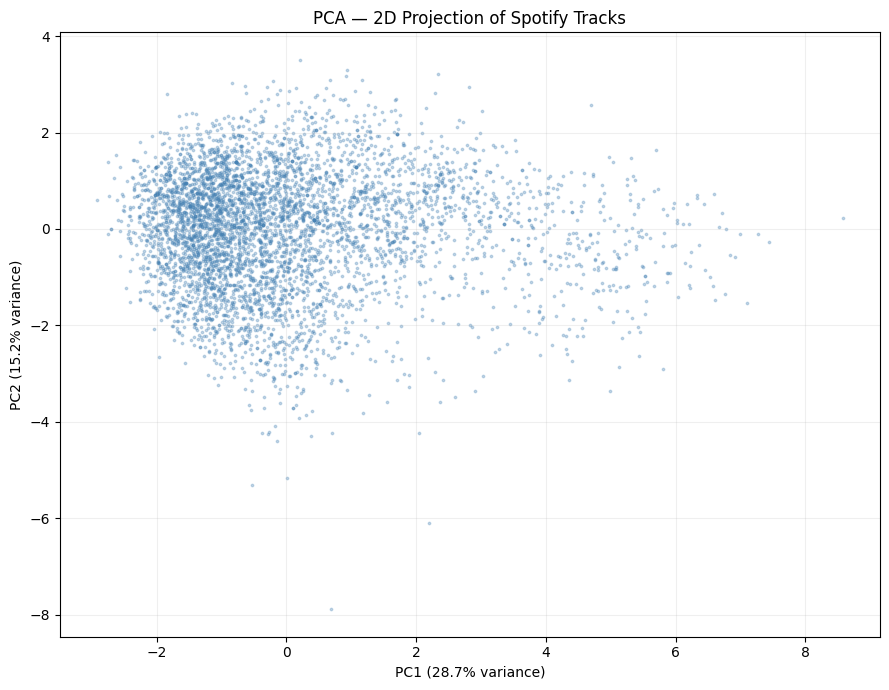

In [53]:
# Extract PC1 and PC2 for a quick scatter plot
# PySpark vectors don't support bracket indexing — convert to array first
from pyspark.ml.functions import vector_to_array

pca_2d = pca_df.withColumn("pca_array", vector_to_array("pca_features")).select(
    F.col("pca_array")[0].alias("PC1"),
    F.col("pca_array")[1].alias("PC2"),
    "track_genre"
).sample(fraction=5000/pca_df.count(), seed=42).toPandas()

plt.figure(figsize=(9, 7))
plt.scatter(pca_2d["PC1"], pca_2d["PC2"], s=3, alpha=0.3, c="steelblue")
plt.xlabel(f"PC1 ({ev[0]:.1%} variance)")
plt.ylabel(f"PC2 ({ev[1]:.1%} variance)")
plt.title("PCA — 2D Projection of Spotify Tracks")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Part 5: K-Means Clustering

### Step 1: Elbow Method

In [54]:
k_values = [2, 3, 4, 5, 6, 8, 10, 12, 15]
costs = []
silhouettes = []

evaluator = ClusteringEvaluator(
    featuresCol="pca_features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

for k in k_values:
    km = KMeans(k=k, featuresCol="pca_features", seed=42, maxIter=20)
    km_model = km.fit(pca_df)
    cost = km_model.summary.trainingCost
    predictions = km_model.transform(pca_df)
    sil = evaluator.evaluate(predictions)
    costs.append(cost)
    silhouettes.append(sil)
    print(f"K={k:2d} → WSSSE={cost:>14,.0f}  Silhouette={sil:.4f}")

K= 2 → WSSSE=       423,417  Silhouette=0.5702
K= 3 → WSSSE=       332,876  Silhouette=0.4277
K= 4 → WSSSE=       288,646  Silhouette=0.4032
K= 5 → WSSSE=       241,000  Silhouette=0.3880
K= 6 → WSSSE=       216,156  Silhouette=0.4720
K= 8 → WSSSE=       162,461  Silhouette=0.3926
K=10 → WSSSE=       141,716  Silhouette=0.4036
K=12 → WSSSE=       124,489  Silhouette=0.3775
K=15 → WSSSE=       108,559  Silhouette=0.3720


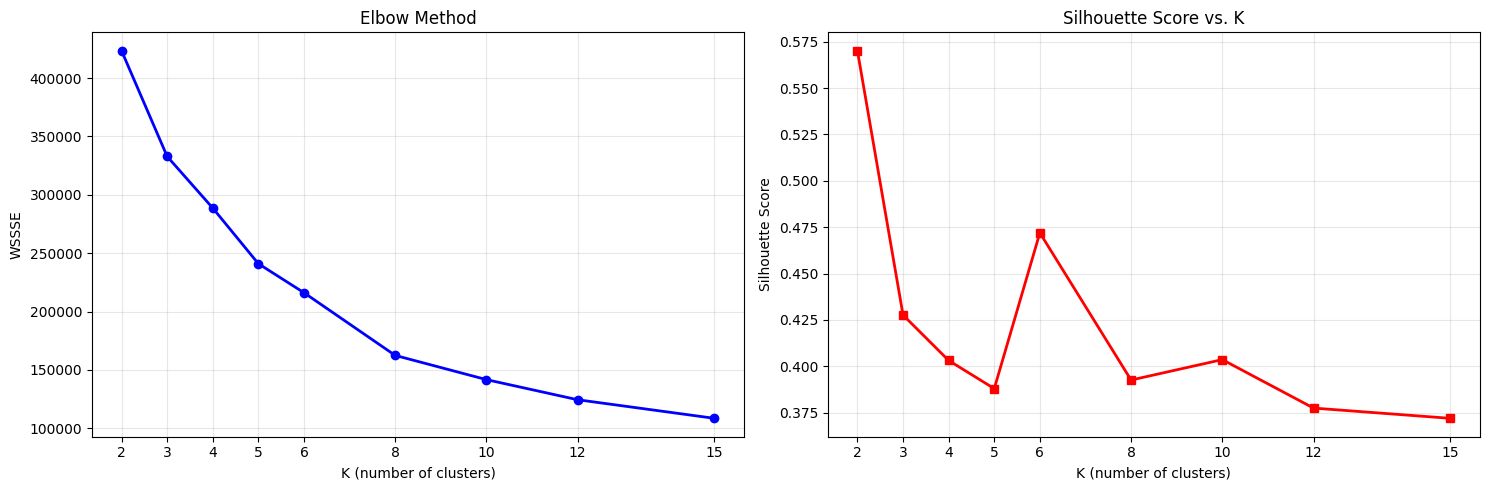

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot
ax1.plot(k_values, costs, 'bo-', linewidth=2)
ax1.set_xlabel("K (number of clusters)")
ax1.set_ylabel("WSSSE")
ax1.set_title("Elbow Method")
ax1.set_xticks(k_values)
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(k_values, silhouettes, 'rs-', linewidth=2)
ax2.set_xlabel("K (number of clusters)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score vs. K")
ax2.set_xticks(k_values)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 2: Fit Final K-Means Model

In [56]:
# Pick K based on elbow + silhouette analysis
best_k = 6  # adjust after seeing the plots above

km_final = KMeans(k=best_k, featuresCol="pca_features", seed=42, maxIter=20)
km_model = km_final.fit(pca_df)
clustered_df = km_model.transform(pca_df)

final_sil = evaluator.evaluate(clustered_df)
print(f"✓ Final model: K={best_k}, Silhouette={final_sil:.4f}")
print(f"  WSSSE: {km_model.summary.trainingCost:,.0f}")

✓ Final model: K=6, Silhouette=0.4720
  WSSSE: 216,156


In [57]:
# Cluster sizes
clustered_df.groupBy("prediction").count().orderBy("prediction").show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|41163|
|         1| 8766|
|         2|29380|
|         3| 9141|
|         4|25514|
|         5|   36|
+----------+-----+



### Cluster centers in PCA space

In [58]:
centers = km_model.clusterCenters()
print("Cluster centers (in PCA space):")
for i, c in enumerate(centers):
    print(f"  Cluster {i}: [{', '.join(f'{v:.3f}' for v in c)}]")

Cluster centers (in PCA space):
  Cluster 0: [-1.141, 0.644, 0.347]
  Cluster 1: [4.202, -0.383, -0.126]
  Cluster 2: [-0.470, -1.388, 0.261]
  Cluster 3: [-0.772, -0.194, -2.635]
  Cluster 4: [1.214, 0.778, 0.120]
  Cluster 5: [1.166, -12.165, 5.143]


## Part 6: Visualization with t-SNE

In [59]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler as SklearnScaler

# Sample 5000 rows and convert to pandas
sample_df = clustered_df.select(
    *audio_features, "track_genre", "prediction"
).sample(fraction=5000/clustered_df.count(), seed=42)

pdf = sample_df.toPandas()
X_sample = pdf[audio_features].values

# Standardize for t-SNE (using sklearn since we're in pandas now)
X_scaled = SklearnScaler().fit_transform(X_sample)

print(f"Sample size: {len(pdf)}")

Sample size: 5114


In [60]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(X_scaled)
pdf["tsne_x"] = tsne_result[:, 0]
pdf["tsne_y"] = tsne_result[:, 1]

print(f"✓ t-SNE complete")

✓ t-SNE complete


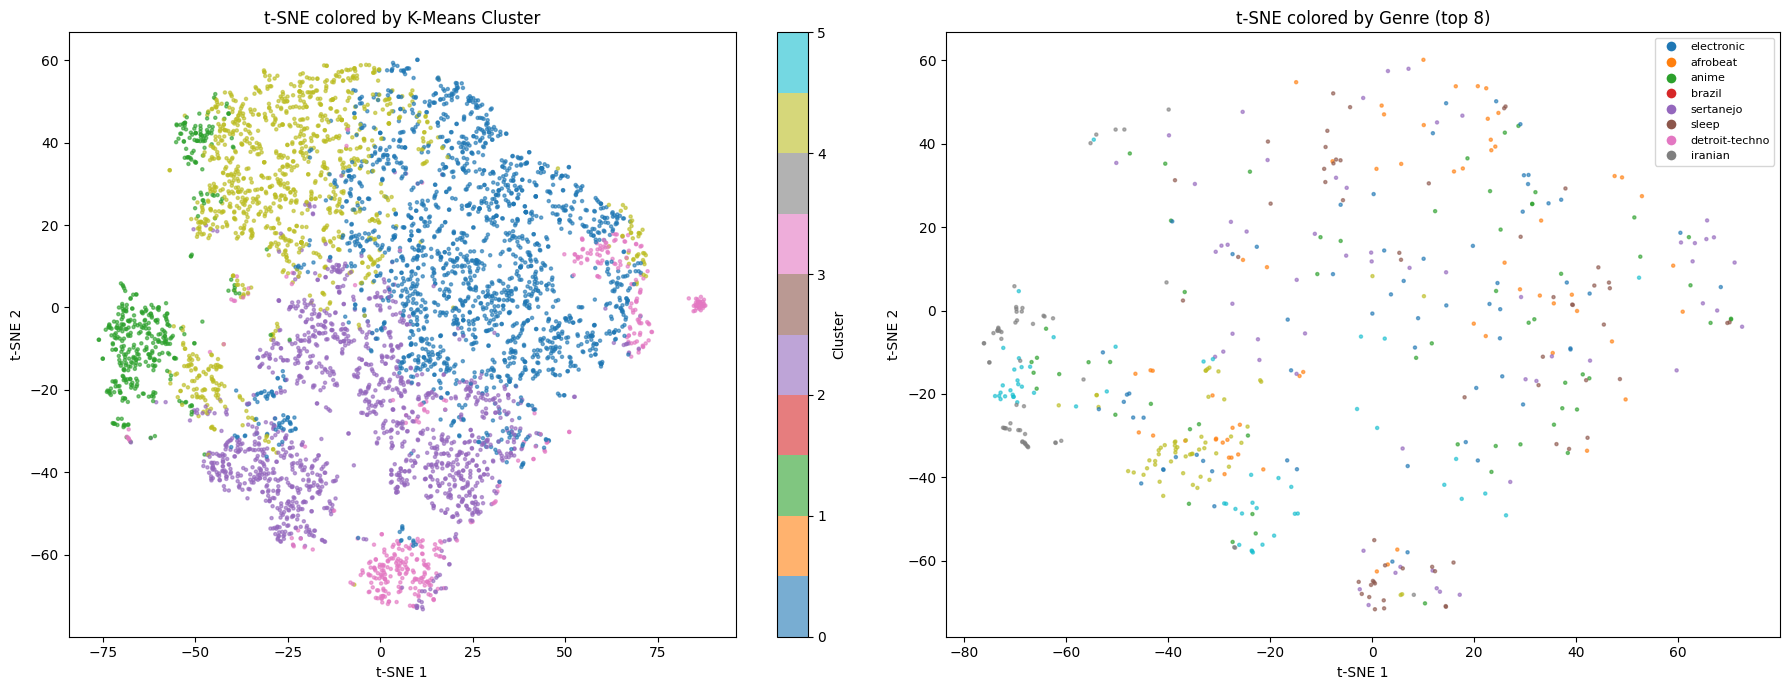

In [61]:
# Side-by-side: K-Means clusters vs. genre labels
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: colored by K-Means cluster
scatter1 = axes[0].scatter(pdf["tsne_x"], pdf["tsne_y"],
                           c=pdf["prediction"], cmap="tab10", s=5, alpha=0.6)
axes[0].set_title("t-SNE colored by K-Means Cluster")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# Plot 2: colored by genre (top 8 for readability)
top_genres = pdf["track_genre"].value_counts().head(8).index.tolist()
genre_subset = pdf[pdf["track_genre"].isin(top_genres)].copy()
genre_codes = {g: i for i, g in enumerate(top_genres)}
genre_subset["genre_code"] = genre_subset["track_genre"].map(genre_codes)

scatter2 = axes[1].scatter(genre_subset["tsne_x"], genre_subset["tsne_y"],
                           c=genre_subset["genre_code"], cmap="tab10", s=5, alpha=0.6)
axes[1].set_title("t-SNE colored by Genre (top 8)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=plt.cm.tab10(i/10), markersize=8, label=g)
           for i, g in enumerate(top_genres)]
axes[1].legend(handles=handles, loc="best", fontsize=8)

plt.tight_layout()
plt.show()

### PCA scatter vs. t-SNE scatter (comparison)

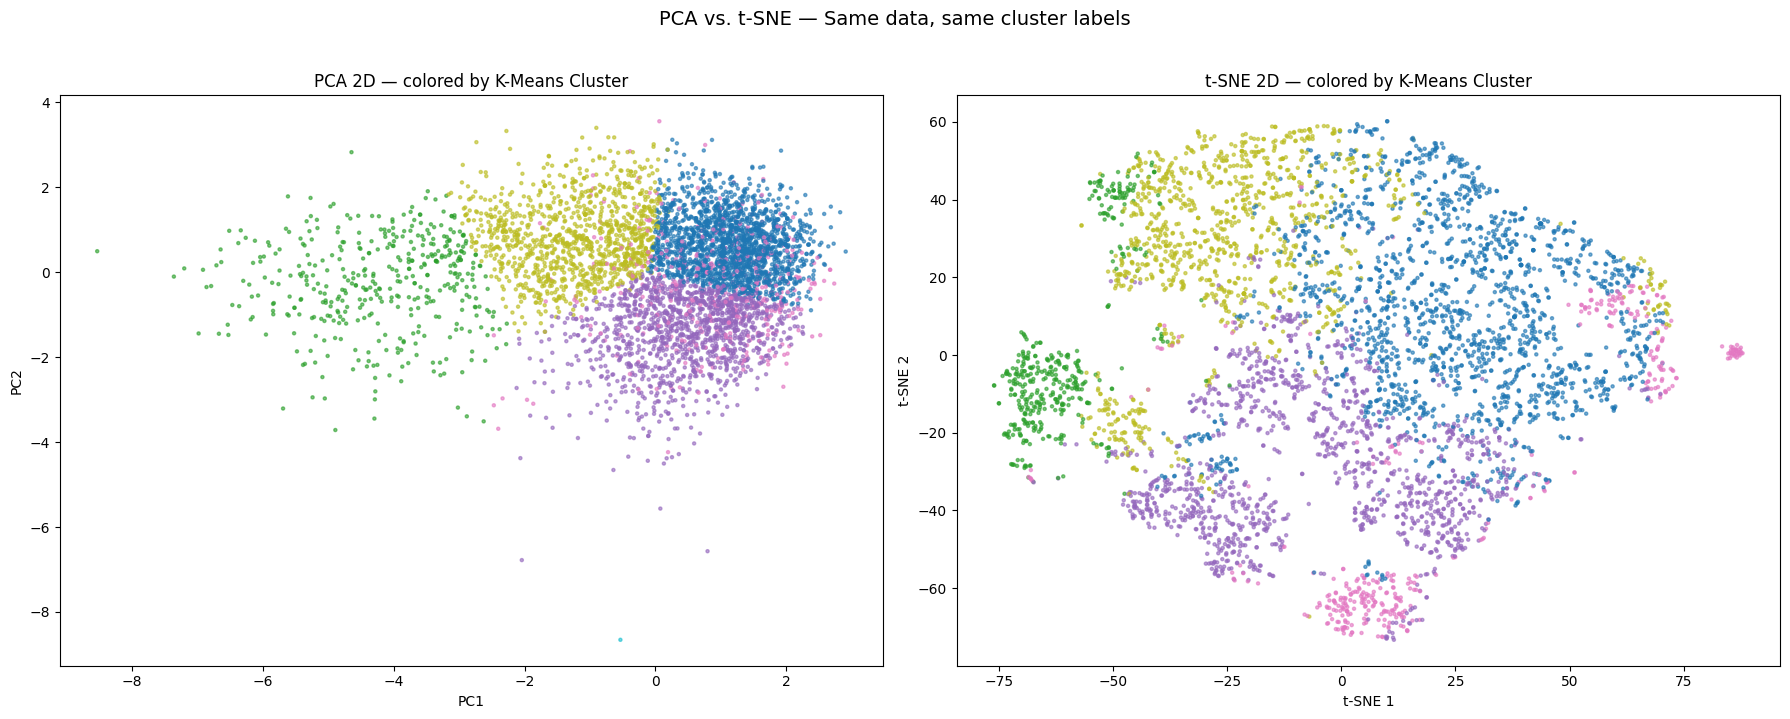

In [62]:
# PCA 2D on the same sample for direct comparison
from sklearn.decomposition import PCA as SklearnPCA

pca_2d_result = SklearnPCA(n_components=2).fit_transform(X_scaled)
pdf["pca_x"] = pca_2d_result[:, 0]
pdf["pca_y"] = pca_2d_result[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(pdf["pca_x"], pdf["pca_y"],
                c=pdf["prediction"], cmap="tab10", s=5, alpha=0.6)
axes[0].set_title("PCA 2D — colored by K-Means Cluster")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(pdf["tsne_x"], pdf["tsne_y"],
                c=pdf["prediction"], cmap="tab10", s=5, alpha=0.6)
axes[1].set_title("t-SNE 2D — colored by K-Means Cluster")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.suptitle("PCA vs. t-SNE — Same data, same cluster labels", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Part 7: Cluster Analysis

### Genre Map — All 114 Genres

Now we zoom out. Using the **full dataset** (all 114 genres), compute the mean audio profile per genre and run t-SNE on just 114 points. Each dot is a genre. Genres that sound similar land next to each other.

We exclude `duration_ms` — it describes track length, not what the music *sounds like*.

In [ ]:
# Genre-level t-SNE map — using df_full (all 114 genres)
from sklearn.preprocessing import StandardScaler as SkScaler

sound_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

# Compute mean audio profile per genre from FULL dataset
genre_profiles = df_full.groupBy("track_genre").agg(
    *[F.avg(f).alias(f) for f in sound_features]
).toPandas()

# Standardize
X_genres = SkScaler().fit_transform(genre_profiles[sound_features].values)

# t-SNE on 114 points — instant
tsne_genres = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=1000)
genre_2d = tsne_genres.fit_transform(X_genres)

# Plot with labels — high DPI for sharp text
fig, ax = plt.subplots(figsize=(16, 12), dpi=150)
ax.scatter(genre_2d[:, 0], genre_2d[:, 1], s=10, alpha=0.7, c="steelblue", zorder=5)

for i, genre in enumerate(genre_profiles["track_genre"]):
    ax.annotate(genre, (genre_2d[i, 0], genre_2d[i, 1]),
                fontsize=7, alpha=0.85, ha="center", va="bottom",
                textcoords="offset points", xytext=(0, 3))

ax.set_title("Genre Map — t-SNE on Mean Audio Profiles (no duration, no genre label)", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

In [ ]:
# Mean audio profile per cluster
cluster_profiles = clustered_df.groupBy("prediction").agg(
    *[F.round(F.avg(f), 3).alias(f) for f in audio_features]
).orderBy("prediction")

cluster_profiles.show(truncate=False)

In [ ]:
# Radar chart of cluster profiles (normalized to 0-1 for visual comparison)
cp = cluster_profiles.toPandas()

# Normalize each feature to 0-1 range across clusters for radar chart
radar_features = [f for f in audio_features if f != "duration_ms"]
cp_norm = cp.copy()
for f in radar_features:
    fmin, fmax = cp[f].min(), cp[f].max()
    if fmax > fmin:
        cp_norm[f] = (cp[f] - fmin) / (fmax - fmin)
    else:
        cp_norm[f] = 0.5

# Radar plot
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for idx, row in cp_norm.iterrows():
    values = [row[f] for f in radar_features]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1.5, label=f"Cluster {int(row['prediction'])}",
            color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=9)
ax.set_title("Cluster Audio Profiles", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Top 5 genres per cluster
from pyspark.sql.window import Window

genre_by_cluster = clustered_df.groupBy("prediction", "track_genre").count()
w = Window.partitionBy("prediction").orderBy(F.desc("count"))
top_genres_per_cluster = genre_by_cluster.withColumn(
    "rank", F.row_number().over(w)
).filter(F.col("rank") <= 5)

top_genres_per_cluster.orderBy("prediction", "rank").show(50, truncate=False)

In [ ]:
# Genre purity: what percentage of each cluster's tracks belong to its top genre?
cluster_sizes = clustered_df.groupBy("prediction").count().withColumnRenamed("count", "total")
top1 = top_genres_per_cluster.filter(F.col("rank") == 1).select(
    "prediction", F.col("track_genre").alias("top_genre"), F.col("count").alias("top_count")
)
purity = top1.join(cluster_sizes, "prediction").withColumn(
    "purity", F.round(F.col("top_count") / F.col("total") * 100, 1)
).orderBy("prediction")

purity.show(truncate=False)

## Part 8: Discussion Questions

**1. Scaling:** `duration_ms` and `tempo` would dominate all distance calculations because their numeric range is orders of magnitude larger than the 0–1 features. K-Means would essentially cluster by duration and tempo, ignoring danceability, energy, etc.

**2. PCA before K-Means:** The curse of dimensionality — in high-dimensional spaces, distances between points converge, making cluster boundaries meaningless. PCA reduces noise dimensions that add distance without adding structure. Also reduces compute.

**3. Clusters vs. genres:** Genre labels are culturally assigned, not acoustically defined. Multiple genres can share audio features (pop and dance have similar energy/danceability). Clusters reflect acoustic similarity, not cultural categories. Neither is "wrong" — they measure different things.

**4. t-SNE vs. PCA:** PCA preserves global linear structure (directions of maximum variance). t-SNE preserves local neighborhood structure non-linearly — nearby points stay nearby, but global distances are distorted. This is why t-SNE shows tighter groups. You can't use t-SNE output as model input because: (a) it's non-deterministic, (b) distances are not meaningful globally, (c) it doesn't generalize to new data (no `.transform()`).

In [ ]:
spark.stop()
print("✓ Done")